# `rioxarray`

In this lesson we will introduce [`rioxarray`](https://corteva.github.io/rioxarray/stable/), a Python extension for `xarray` to manipulate `xarray.DataArray`s as rasters. 

The name `rioxarray` stands for *raster input/output + xarray*. 

## About the data
The raster files we will use today come from the [US National Agriculture Imagery Program (NAIP)](https://naip-usdaonline.hub.arcgis.com). 
NAIP images are are high-resolution aerial images with four spectral bands: red (R), green (G), blue (B) and near-infrared (NIR). 
The raster's we'll use today are from 2020.

The data used in this lesson was pre-processed from a complete NAIP scene to separate the RGB bands from the NIR band and reduce the spatial extent. 
The data was accessed through [Microsoft's Planetary Computer NAIP data repository](https://planetarycomputer.microsoft.com/dataset/naip#overview).

## Import a TIF file

Let's start by loading the libraries we will use: 

In [5]:
import os 

import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray as rioxr


In [2]:
# Import NIR TIF file 
# Make sure this is the path to the data folder containing 
root = os.path.join('data','NAIP_SB')

There are [multiple ways of opening a TIF file using `xarray` or `rioxarray`](https://corteva.github.io/rioxarray/html/getting_started/getting_started.html). 
Using the `rioxarray.open_rasterio()` function to open the TIF file is a simple way to import the raster file as an `xarray.DataArray` and make sure all our geospatial data gets loaded correctly:

In [ ]:
# Import NIR TIF file
# Make sure this is the PATH TO THE DATA FOLDER CONTAINING THE RASTERS
root = os.path.join('data', 'rioxarray_lesson_data')


In [6]:
nir = rioxr.open_rasterio(os.path.join(root, 'NAIP_SB_NIR.tif'))
nir


<xarray.DataArray (band: 1, y: 3208, x: 2419)> Size: 8MB
[7760152 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [8]:
nir.values


array([[[167, 164, 161, ..., 147, 152, 151],
        [170, 170, 168, ..., 151, 149, 154],
        [176, 177, 177, ..., 151, 151, 151],
        ...,
        [ 94,  88, 101, ...,  83,  88,  79],
        [108,  95, 103, ...,  92,  91,  75],
        [ 94,  90, 104, ...,  87,  88,  82]]], dtype=uint8)

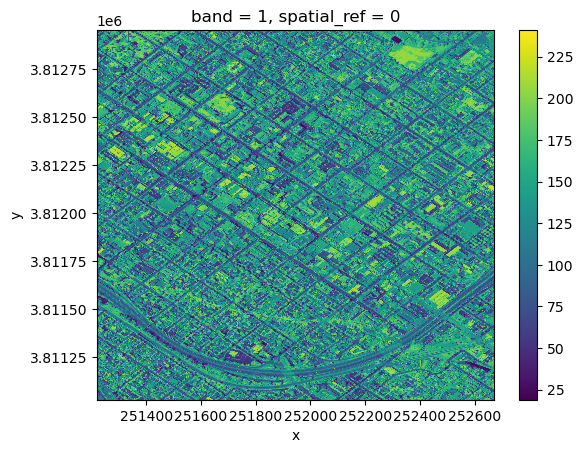

In [10]:
nir.plot()

## Drop a dimensionn
Our raster has an unnecessary extra dimension: band 

In [11]:
print("Size of dimensions",dict(nir.sizes))

Size of dimensions {'band': 1, 'y': 3208, 'x': 2419}


We can "squeeze the dimnensions" of length 1 by:
1. Using the 'squeeze()' method. no parameters = gets rid of all dimensions of length one
2. Removing associated coordinates for this dimension using `drop()`


In [12]:
print(nir.dims, nir.coords)

('band', 'y', 'x') Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0


In [14]:
nir = nir.squeeze()
print(nir.dims, '\n', nir.coords)

('y', 'x') 
 Coordinates:
    band         int64 8B 1
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0


In [ ]:
# Remove coordinates associated with 'band' dimension
nir = nir.drop_vars('band')
print(nir.dims, '\n', nir.coords)

('y', 'x') 
 Coordinates:
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0


## `rio` accessor

Use the `.rio` accessor for an `xarray.DataArray` to access its raster properties.

Examples:

In [17]:
print('Number of bands:', nir.rio.count)
print('Height:', nir.rio.height)
print('Width:', nir.rio.width)

print('Spatial bounding box: \n', nir.rio.bounds())
print('CRS:', nir.rio.crs)

Number of bands: 1
Height: 3208
Width: 2419
Spatial bounding box: 
 (251218.8, 3811027.2, 252670.19999999998, 3812952.0)
CRS: EPSG:26911


## Multi-band raster

In [22]:
# Import RGB raster
rgb = rioxr.open_rasterio(os.path.join('data','NAIP_SB', 'NAIP_SB_RGB.tif'))

rgb

<xarray.DataArray (band: 3, y: 3208, x: 2419)> Size: 23MB
[23280456 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 19kB 2.512e+05 2.512e+05 ... 2.527e+05 2.527e+05
  * y            (y) float64 26kB 3.813e+06 3.813e+06 ... 3.811e+06 3.811e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [23]:
print('CRS:', rgb.rio.crs)

CRS: EPSG:26911


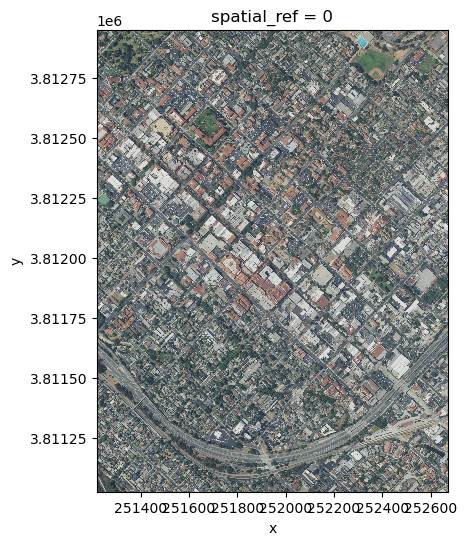

In [24]:
# Plot three bands as RGB image
rgb_aspect_ratio = rgb.rio.width / rgb.rio.height # Raster's aspect ratio
rgb.plot.imshow(size = 6, # Plot's height in inches
                aspect = rgb_aspect_ratio
                ) # Aspect ratio of the plot

<Axes: >

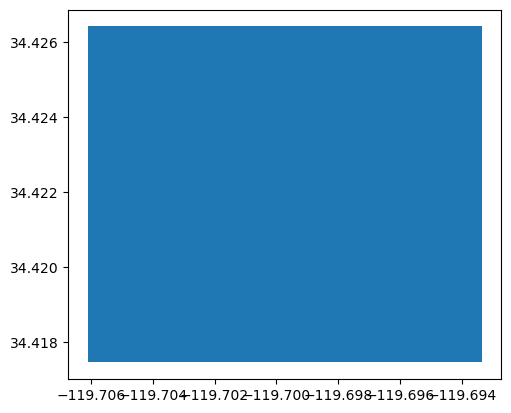

In [26]:
aoi = gpd.read_file(os.path.join('data','SB_aoi.geojson'))
aoi.plot()

In [29]:
# Examine CRS
print('aoi CRS:', aoi.crs)  # json files always use EPSG:4326
print('nir CRS:', nir.rio.crs)
print('rgb CRS:', rgb.rio.crs) 

aoi CRS: EPSG:4326
nir CRS: EPSG:26911
rgb CRS: EPSG:26911


In [32]:
# Reproject AOI to RGB CRS
aoi = aoi.to_crs(rgb.rio.crs)
print('Matched CRS?',  aoi.crs == rgb.rio.crs)

Matched CRS? True


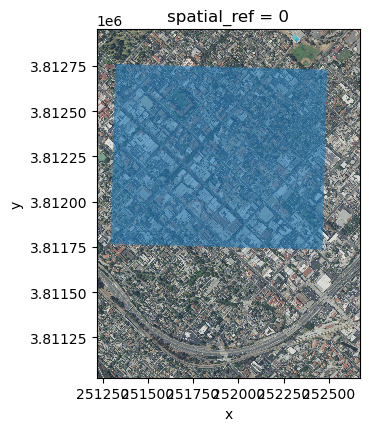

In [33]:
# Plot of RGB raster with AOI overlay
fig, ax = plt.subplots(figsize=(6, 6 * rgb_aspect_ratio))  # Directly set size and aspect
rgb.plot.imshow(ax=ax)
aoi.plot(ax=ax, alpha=0.6)
plt.show()

To clip raster using the AOI polygon with the `rioxarray` library, we can use the `rio.clip_box()` method

In [34]:
# Clip rasters to AOI
rgb_small = rgb.rio.clip_box(*aoi.total_bounds)
nir_small = nir.rio.clip_box(*aoi.total_bounds)

Original shape: (3208, 2419)
Clipped shape: (1710, 1995)


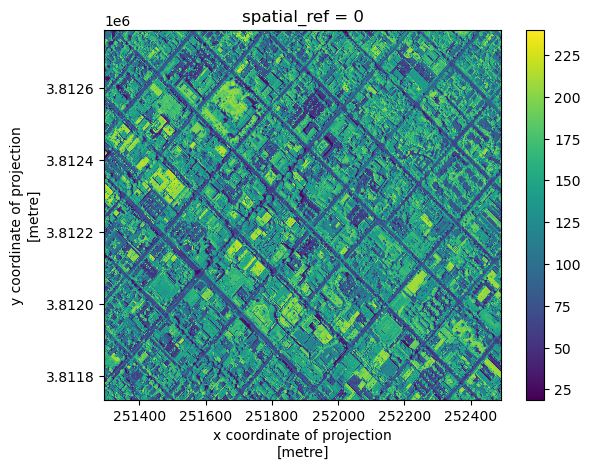

In [35]:
print('Original shape:', nir.shape)
print('Clipped shape:', nir_small.shape)

nir_small.plot()

## Raster math
We often want perform calculations on rasters to create a new output raster, commonly known as “raster math”.

In our case, we are interested in computing the Normalized Difference Vegetation Index (NDVI) over our AOI. The NDVI is an index commonly used to check if an area has live green vegetation or not.

The results of the NDVI calculation range from -1 to 1.
- Negative values correspond to areas with water surfaces, manmade structures, rocks, clouds, snow
- Bare soil usually falls within 0.1-0.2 range
- Plants will always have positive values between 0.2 and 1.
- Healthy, dense vegetation canopy should be above 0.5
- Sparse vegetation will most likely fall within 0.2 to 0.5.

NDVI is calculated using the NIR and red bands. The formula is 

```python
NDVI = (NIR - Red) / (NIR + Red)
```

$$ NDVI = \frac{NIR - Red}{NIR + Red} $$

In [36]:
# Select red band dimension by name and coordinate by label
red = rgb_small.sel(band=1)
red

<xarray.DataArray (y: 1710, x: 1995)> Size: 3MB
[3411450 values with dtype=uint8]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 16kB 2.513e+05 2.513e+05 ... 2.525e+05 2.525e+05
  * y            (y) float64 14kB 3.813e+06 3.813e+06 ... 3.812e+06 3.812e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [40]:
ndvi = (nir - red) / (nir + red)

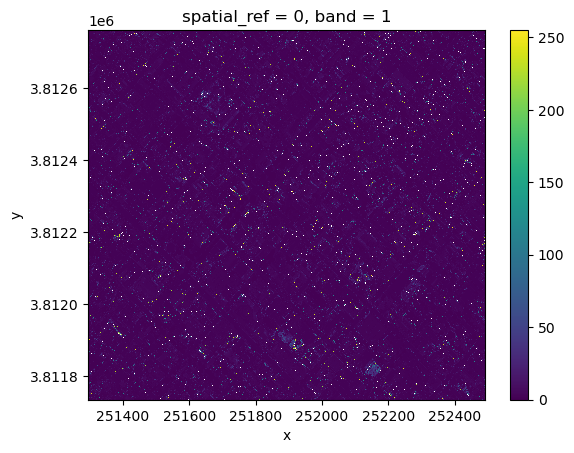

In [41]:
ndvi.plot()

## Data Type 
The `uint8` (8-bit unsigned integer) is a very small data type that only holds integers from 0 up to 255. In particular, calculations don’t return what what we are used to when working with intgers (they’re done module 255):


In [43]:
# Calculation with uint8 data type can produce unexpected results
np.uint8(150) + np.uint8(150)  # Expected 350, but wraps around at 255 and returns 44 

/var/folders/4b/mtnmj40n3nq_005xml4c9x600000gn/T/ipykernel_69150/3582944263.py:2: RuntimeWarning: overflow encountered in scalar add
  np.uint8(150) + np.uint8(150)  # Expected 350, but wraps around at 255 and returns 44


44

## Updating data types
To be able to perform the calculation successfully, we will need to udpate the data type of our rasters into int16, which will be big enough to hold all the numbers that appear in the calculations:

In [46]:
# Update data type of rasters to int16 to perform NDVI
red16 = red.astype('int16') # this is called 'casting' red as data type int16
nir16 = nir_small.astype('int16') 

print('RED - original dtype: ', red.dtype, '...... converted dtype:', red16.dtype)
print('RED - original dtype: ', nir.dtype, '...... converted dtype:', nir16.dtype)

RED - original dtype:  uint8 ...... converted dtype: int16
RED - original dtype:  uint8 ...... converted dtype: int16


In [47]:
# Calculate NDVI
ndvi = (nir16 - red16)/(nir16+red16)

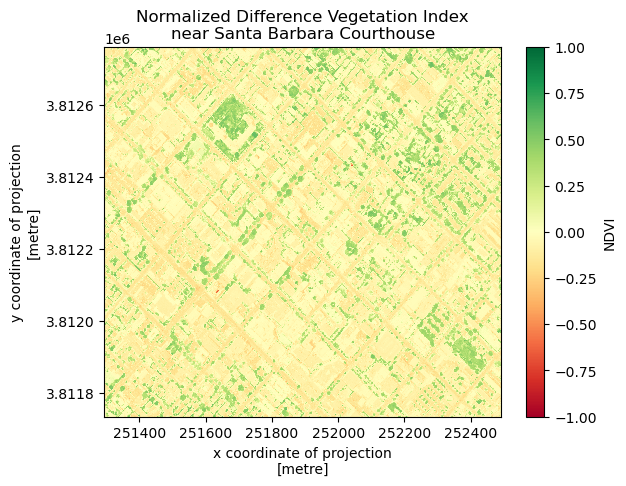

In [51]:
# Plot
fig, ax = plt.subplots()

ndvi.plot(ax=ax,
          cmap='RdYlGn', 
          vmin = -1,
          vmax = 1,
          cbar_kwargs={"label": "NDVI"}  # Label for color bar
)

ax.set_title("Normalized Difference Vegetation Index\nnear Santa Barbara Courthouse")  # Add title



plt.show()
